In [1]:
import sys
sys.path.insert(0, '../src')

import torch
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger

from config import load_config
from dataset_coco import COCOInstanceDataset
from models import Mask2Former
from lightning_module import SegmentationModule

In [ ]:
config = load_config('../configs/config_coco_mask2former_semantic.json')

DATA_ROOT = config['data']['root_dir']
TRAIN_SPLIT = config['data']['split']
VAL_SPLIT = config['data']['val_split']
TEST_SPLIT = config['data']['test_split']
TARGET_SIZE = tuple(config['data']['target_size'])
BATCH_SIZE = config['data']['batch_size']
NUM_WORKERS = config['data']['num_workers']
MIN_AREA = config['data']['min_area']
MODE = config['data']['mode']
NUM_CLASSES = config['model']['num_classes']
NUM_CLASSES_WITH_BG = NUM_CLASSES + 1

NUM_QUERIES = config['model']['num_queries']
HIDDEN_DIM = config['model']['hidden_dim']
NHEADS = config['model']['nheads']
NUM_DECODER_LAYERS = config['model']['num_decoder_layers']

MAX_EPOCHS = config['training']['max_epochs']
LEARNING_RATE = config['training']['learning_rate']

print(f"Model: Mask2Former")
print(f"Classes: {NUM_CLASSES}")


Model: Mask2Former
Task: Semantic Segmentation (from instance annotations)
Dataset: COCO val2017
Classes: 1
Queries: 100, Hidden dim: 256
Batch size: 4
Mode: instance


In [ ]:
train_dataset = COCOInstanceDataset(
    root_dir=DATA_ROOT,
    split=TRAIN_SPLIT,
    target_size=TARGET_SIZE,
    min_area=MIN_AREA,
    mode=MODE
)

test_dataset = COCOInstanceDataset(
    root_dir=DATA_ROOT,
    split=TEST_SPLIT,
    target_size=TARGET_SIZE,
    min_area=MIN_AREA,
    mode=MODE
)

val_dataset = COCOInstanceDataset(
    root_dir=DATA_ROOT,
    split=VAL_SPLIT,
    target_size=TARGET_SIZE,
    min_area=MIN_AREA,
    mode=MODE
)

print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')
print(f'Classes: {train_full_dataset.class_names}')


loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Loaded 865 images with annotations for train split (mode: instance)
Classes: 2 (0=background + 1 COCO categories)
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Loaded 253 images with annotations for test split (mode: instance)
Classes: 2 (0=background + 1 COCO categories)
Train samples: 735
Val samples: 130
Test samples: 253
Classes: ['background', 'person']


In [4]:
def collate_fn(batch):
    images = torch.stack([item[0] for item in batch])
    masks = [item[1] for item in batch]
    labels = [item[2] for item in batch]
    return images, masks, labels

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_fn
)


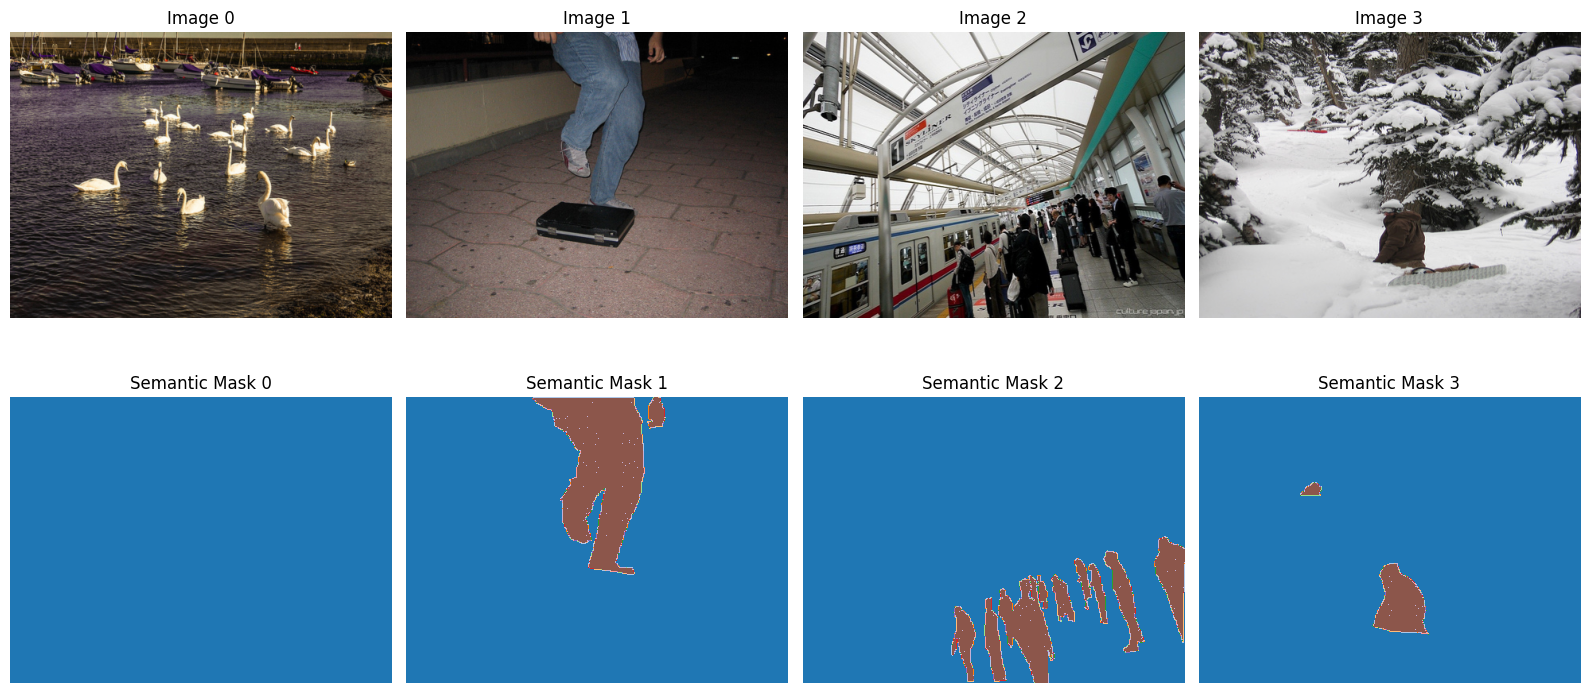

Batch size: 4
Image shape: torch.Size([3, 360, 480])
Instances per image: [1, 1, 11, 2]
Semantic mask shape: torch.Size([4, 360, 480])


In [5]:
import matplotlib.pyplot as plt
import numpy as np

sample_images, sample_masks, sample_labels = next(iter(train_loader))

# Convert instance masks to semantic for visualization
B = len(sample_masks)
H, W = sample_masks[0].shape[-2:]
semantic_masks = torch.zeros(B, H, W, dtype=torch.long)

for b in range(B):
    for i in range(sample_masks[b].shape[0]):
        mask = sample_masks[b][i] > 0.5
        label = sample_labels[b][i]
        if label > 0:
            semantic_masks[b][mask] = label

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(min(4, len(sample_images))):
    img = sample_images[i].cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    img = np.clip(img, 0, 1)
    
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Image {i}')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(semantic_masks[i], cmap='tab20', vmin=0, vmax=NUM_CLASSES_WITH_BG)
    axes[1, i].set_title(f'Semantic Mask {i}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print(f'Batch size: {len(sample_images)}')
print(f'Image shape: {sample_images[0].shape}')
print(f'Instances per image: {[len(m) for m in sample_masks]}')
print(f'Semantic mask shape: {semantic_masks.shape}')


In [6]:
model = Mask2Former(
    num_classes=NUM_CLASSES,
    num_queries=NUM_QUERIES,
    emb_dim=HIDDEN_DIM,
    nhead=NHEADS,
    nlayers=NUM_DECODER_LAYERS
)

model = SegmentationModule(
    model=model,
    num_classes=NUM_CLASSES,
    learning_rate=LEARNING_RATE,
    weight_decay=config['training']['weight_decay'],
    optimizer='adamw'
)

print(f"Mask2Former model created for COCO semantic segmentation")
print(f"  Transformer queries: {NUM_QUERIES}")
print(f"  Embedding dimension: {HIDDEN_DIM}")
print(f"  Attention heads: {NHEADS}")
print(f"  Decoder layers: {NUM_DECODER_LAYERS}")


Using cache found in /home/tam2511/.cache/torch/hub/pytorch_vision_v0.10.0
/home/tam2511/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/tam2511/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Mask2Former model created for COCO semantic segmentation
  Transformer queries: 100
  Embedding dimension: 256
  Attention heads: 8
  Decoder layers: 3


In [7]:
checkpoint_callback = ModelCheckpoint(
    dirpath=config['training']['checkpoint_dirpath'],
    filename=config['training']['checkpoint_filename'],
    save_top_k=config['training']['checkpoint_save_top_k'],
    monitor='val_iou',
    mode='max'
)

early_stopping = EarlyStopping(
    monitor='val_iou',
    patience=config['training']['early_stopping_patience'],
    mode='max'
)

logger = TensorBoardLogger(
    save_dir=config['training']['log_dir'],
    name=config['training']['experiment_name']
)


In [8]:
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    callbacks=[checkpoint_callback, early_stopping],
    logger=logger,
    accelerator=config['hardware']['accelerator'],
    devices=config['hardware']['devices'],
    log_every_n_steps=config['training']['log_every_n_steps']
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [9]:
trainer.fit(model, train_loader, val_loader)


You are using a CUDA device ('NVIDIA L40') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/home/tam2511/.local/lib/python3.8/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:652: Checkpoint directory /home/tam2511/mounts/0/arcadia/market/robotics/cv/ml/user_data/shad/seg/checkpoints_coco_mask2former_semantic_1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.

  | Name       | Type                   | Params
------------------------------------------------------
0 | model      | Mask2Former            | 113 M 
1 | train_loss | MeanMetric             | 0     
2 | val_loss   | MeanMetric             | 0     
3 | val_iou    | Multicla

Sanity Checking: |          | 0/? [00:00<?, ?it/s]


[DEBUG Targets] Batch 0:
  Num samples: 4
  Sample 0: 1 instances, labels: [0]
  Sample 1: 12 instances, labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

[DEBUG Loss] Before matching:
  target_classes filled with: 1 (no_object)
  Matches in batch:
    Sample 0: 1 matches, GT labels: [0]
    Sample 1: 12 matches, GT labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Final target_classes unique: tensor([0, 1], device='cuda:0')
  target_classes distribution: 0=19, 1=381

[DEBUG Postprocess] Batch 0:
  Queries: 100, Classes: 2
  no_object_idx: 1
  pred_classes unique: tensor([0, 1], device='cuda:0')
  max_probs range: [0.502, 0.880]
  Valid queries: 70 / 100
  conf_threshold: 0.5

[DEBUG Val] Epoch 0, Batch 0:
  Predictions unique: tensor([1], device='cuda:0')
  Targets unique: tensor([0, 1], device='cuda:0')
  Preds shape: torch.Size([4, 360, 480]), Targets shape: torch.Size([4, 360, 480])
[Epoch 0] Val Loss: 22.9616 | Val mIoU: 1.0000


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

[Epoch 14] Val Loss: 8.0928 | Val mIoU: 0.7747

[Epoch 14] Train Loss: 5.0549 | LR: 8.11e-05


Validation: |          | 0/? [00:00<?, ?it/s]


[DEBUG Targets] Batch 0:
  Num samples: 4
  Sample 0: 1 instances, labels: [0]
  Sample 1: 12 instances, labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

[DEBUG Loss] Before matching:
  target_classes filled with: 1 (no_object)
  Matches in batch:
    Sample 0: 1 matches, GT labels: [0]
    Sample 1: 12 matches, GT labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Final target_classes unique: tensor([0, 1], device='cuda:0')
  target_classes distribution: 0=19, 1=381

[DEBUG Postprocess] Batch 0:
  Queries: 100, Classes: 2
  no_object_idx: 1
  pred_classes unique: tensor([0, 1], device='cuda:0')
  max_probs range: [0.603, 1.000]
  Valid queries: 1 / 100
  conf_threshold: 0.5

[DEBUG Val] Epoch 15, Batch 0:
  Predictions unique: tensor([0, 1], device='cuda:0')
  Targets unique: tensor([0, 1], device='cuda:0')
  Preds shape: torch.Size([4, 360, 480]), Targets shape: torch.Size([4, 360, 480])
[Epoch 15] Val Loss: 8.8471 | Val mIoU: 0.6883

[Epoch 15] Train Loss: 4.6970 | LR: 7.50e-05


Validation: |          | 0/? [00:00<?, ?it/s]

[Epoch 16] Val Loss: 8.3057 | Val mIoU: 0.7234

[Epoch 16] Train Loss: 4.3957 | LR: 6.82e-05


In [ ]:
from torchmetrics import JaccardIndex
from tqdm.notebook import tqdm

print("\n" + "="*70)
print("TESTING ON HELD-OUT TEST SET")
print("="*70)

# DEBUG: Check model num_classes
print(f"Model num_classes: {model.model.num_classes}")
print(f"Model class_head output size: {model.model.class_head.out_features}")

model.eval()
test_iou = JaccardIndex(
    task='multiclass',
    num_classes=NUM_CLASSES_WITH_BG,
    average='macro',
    ignore_index=0
).to(model.device)

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(test_loader)):
        images, instance_masks, instance_labels = batch
        images = images.to(model.device)
        
        outputs = model(images)
        preds = model.model.postprocess(outputs, mode='semantic')
        
        # DEBUG: Check predictions on first batch
        if batch_idx == 0:
            print(f"\nDEBUG First batch:")
            print(f"  Predictions unique values: {torch.unique(preds)}")
            print(f"  Predictions min/max: {preds.min()}/{preds.max()}")
        
        semantic_targets = model._instance_to_semantic(
            instance_masks, instance_labels, device=model.device
        )
        
        test_iou.update(preds, semantic_targets)

final_test_iou = test_iou.compute()

print(f"\n✓ Test mIoU: {final_test_iou:.4f}")
print("="*70)



TESTING ON HELD-OUT TEST SET
Model num_classes: 1
Model class_head output size: 2


  0%|          | 0/64 [00:00<?, ?it/s]

In [ ]:
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

sample_images, sample_masks = next(iter(val_loader))
sample_images = sample_images.to(device)

with torch.no_grad():
    outputs = model(sample_images)
    predictions = model.model.postprocess(outputs, mode='semantic')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i in range(min(2, len(sample_images))):
    img = sample_images[i].cpu().numpy().transpose(1, 2, 0)
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Input Image')
    axes[i, 0].axis('off')
    
    gt_mask = sample_masks[i].cpu().numpy()
    axes[i, 1].imshow(gt_mask, cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title(f'Ground Truth ({gt_mask.sum()} person pixels)')
    axes[i, 1].axis('off')
    
    pred_mask = predictions[i].cpu().numpy()
    axes[i, 2].imshow(pred_mask, cmap='gray', vmin=0, vmax=1)
    axes[i, 2].set_title(f'Prediction ({pred_mask.sum()} person pixels)')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()
